In [ ]:
import sys
import numpy as np
import cv2
from matplotlib import pyplot as plt
sys.path.append('../robot')
from common import arena
from common.poses import Poses
from observation_models.distance import DistanceObservationModel

In [2]:
low_probability = 0.1
# Ranges for world x and y coordinates, indexed by map coordinates
map_frame = arena.MapFrame(100)

In [9]:
def plot_map(map_data, axs=None):
    if axs is None:
        plt.figure(figsize=(8, 8))    
        axs = plt
    axs.imshow(
        map_data,
        cmap='gray_r',
        origin='lower',
        extent=[map_frame.w_left, map_frame.w_right, map_frame.w_bottom, map_frame.w_top],
        aspect='equal'
    )

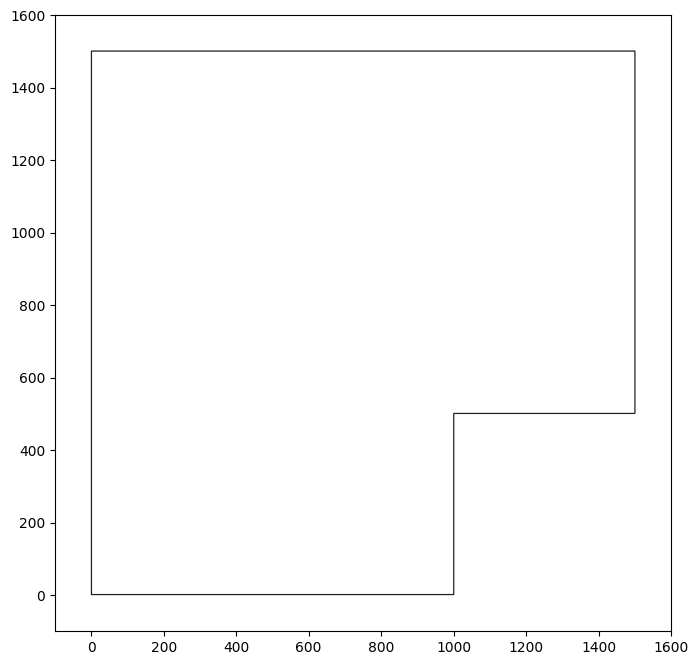

In [10]:
walls_map = np.zeros((map_frame.height, map_frame.width), dtype=np.float32)
cv2.polylines(walls_map, 
              map_frame.world_to_map(np.array([arena.walls])), 
              isClosed=True, color=1.0, thickness=2)

plot_map(walls_map)

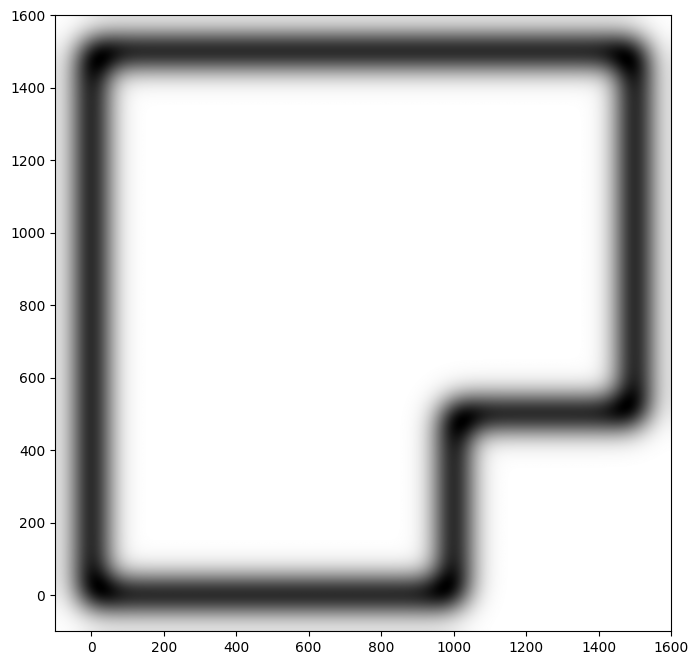

In [5]:
distance_map = cv2.GaussianBlur(walls_map, (0, 0), 45)
plot_map(distance_map)

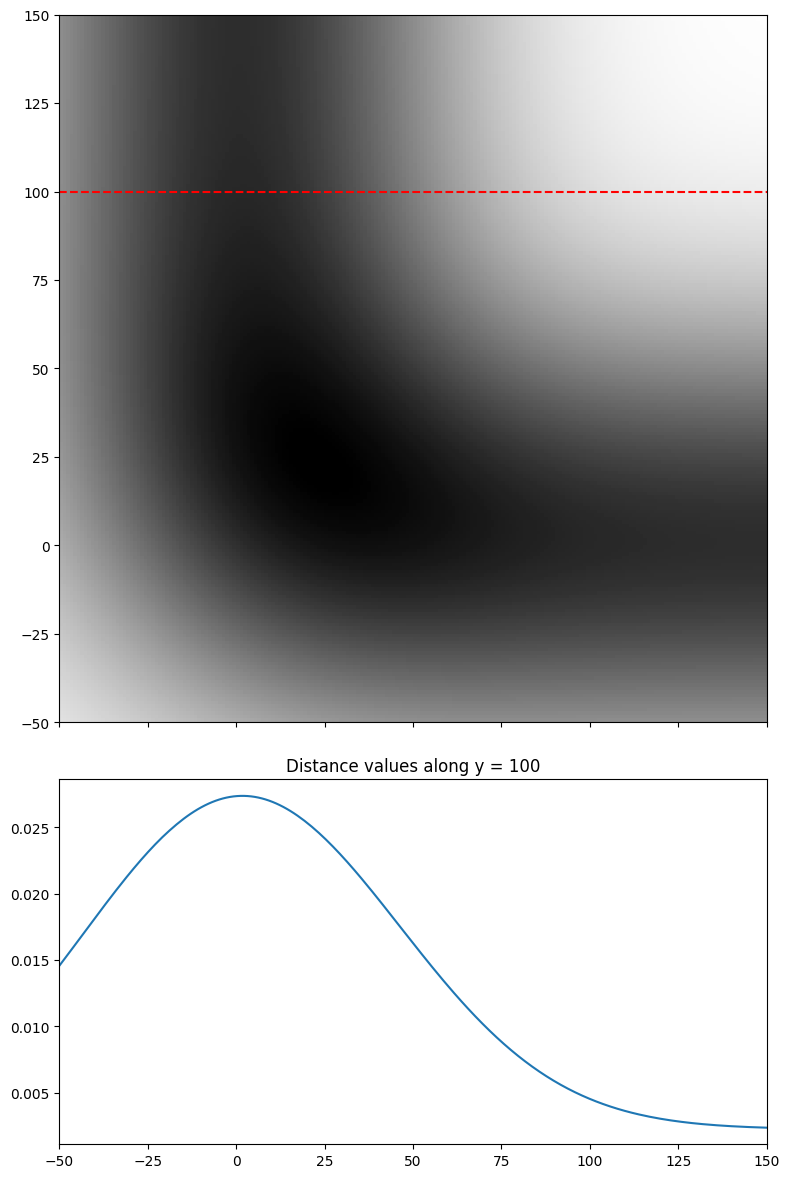

In [14]:
# Plot map and sampled row in a vertical stack with aligned x-axes
fig, (ax_map, ax_row) = plt.subplots(
    2, 1, figsize=(8, 12), sharex=True,
    gridspec_kw={"height_ratios": [4, 2]}
 )

# Top plot: distance map with sampling line
plot_map(distance_map, axs=ax_map)
ax_map.set_xlim(-50, 150)
ax_map.set_ylim(-50, 150)
ax_map.axhline(y=100, color='r', linestyle='--')
ax_map.tick_params(labelbottom=False)

# Bottom plot: values along y=100 (projection of the dashed line above)
map_y = 100 + map_frame.margin
row = distance_map[map_y, 50:250]
ax_row.plot(np.linspace(-50, 150, 200), row)
ax_row.set_title('Distance values along y = 100')
ax_row.set_xlim(-50, 150)

fig.tight_layout()

In [15]:
np.min(distance_map), np.max(distance_map)

(np.float32(0.0), np.float32(0.032393876))

(np.float32(0.1), np.float32(1.0))

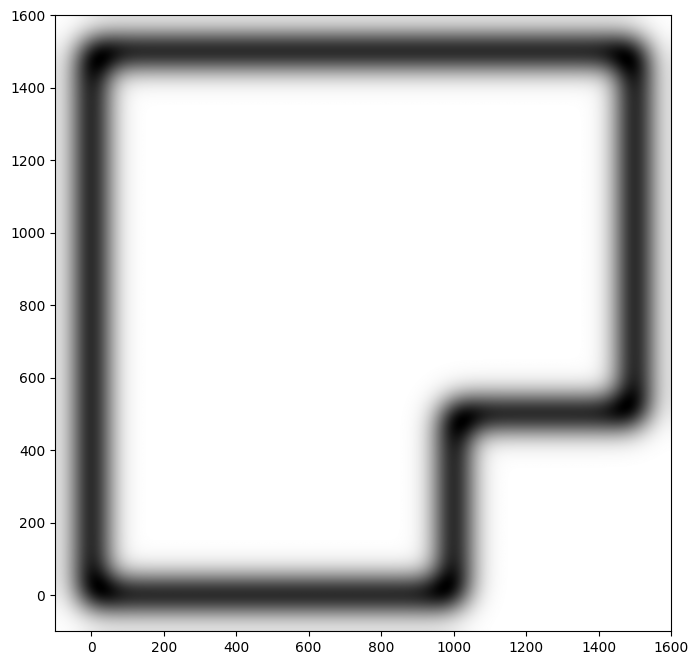

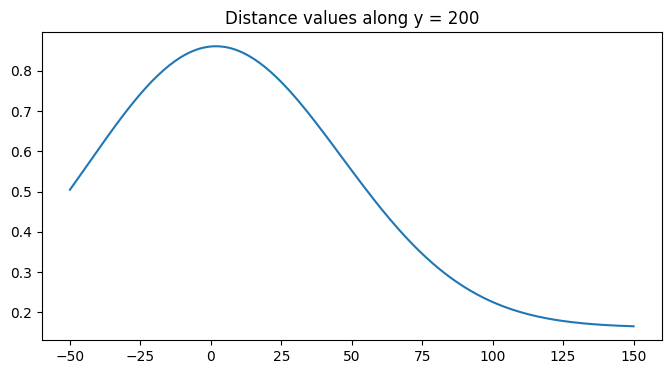

In [ ]:
normalized_map = cv2.normalize(distance_map, None, alpha=low_probability, beta=1.0, norm_type=cv2.NORM_MINMAX)
plot_map(normalized_map)

row = normalized_map[map_y, 50:250]
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(-50, 150, 200), row)
plt.title(f'Distance values along y = {map_y}')
np.min(normalized_map), np.max(normalized_map)

In [ ]:
np.save('../robot/observation_models/distance_map.npy', normalized_map)

In [ ]:
model = DistanceObservationModel("../robot/observation_models/distance_map.npy")
world_positions = np.array([[0, 0], [1705, 1500], [1500, 1200], [400, 400]])
model.get_probabilities(world_positions)

array([0.83666176, 0.1       , 0.83884484, 0.1       ])